<a href="https://colab.research.google.com/github/jiyuutheosum/Machine-Learning/blob/main/Machine_Learning_PIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: [ Jalanie Baraocor ] [ Sherri Nicole Tilan ]**

**BSIT - 4R8 - Machine Learning**

## **1. Importing libraries**

In [40]:
!jupyter nbconvert --clear-output --inplace Machine Learning - PIT.ipynb

[NbConvertApp] WARNING | pattern 'Machine' matched no files
[NbConvertApp] WARNING | pattern 'Learning' matched no files
[NbConvertApp] WARNING | pattern '-' matched no files
[NbConvertApp] WARNING | pattern 'PIT.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equi

In [6]:
# === Install & downloads (run once in Colab) ===
# !pip install -q pyspellchecker
# !pip install -q scikit-learn
# !pip install -q transformers datasets evaluate
# !pip install shap
# !pip install -q transformers torch datasets accelerate

import re
import joblib
import io
import shap
import nltk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import hf_xet

from tqdm import tqdm
from huggingface_hub import HfFolder
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
from google.colab import files

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer   # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences   # type: ignore
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Embedding, Dense, Dropout, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping     # type: ignore

import os
import math
from collections import Counter
from tqdm.auto import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_linear_schedule_with_warmup


# NLTK downloads
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **2. Load Dataset**

In [8]:
print("Upload your dataset (.xlsx or .csv)")
uploaded = files.upload()   # Opens the file picker UI

# Automatically detect the uploaded file name
file_name = next(iter(uploaded))

# Load Excel or CSV
if file_name.endswith(".xlsx"):
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
elif file_name.endswith(".csv"):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
else:
    raise ValueError("Unsupported file type. Please upload .xlsx or .csv")

print("\nDataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Upload your dataset (.xlsx or .csv)


Saving full-translated-to-eng-dataset2.xlsx to full-translated-to-eng-dataset2.xlsx

Dataset loaded successfully!
Shape: (46546, 3)


,sents,sentiments,topics
0,Full course slides .,2,1
1,"Enthusiastic teaching, close to students.",2,0
2,Attend school with full marks for attendance.,0,1
3,have not yet applied information technology an...,0,0
4,"The teacher teaches well, there are many examp...",2,0


# **3. Label Mapping**

In [9]:
# 1. Define your column names directly
TEXT_COL = "sents"
LABEL_COL = "sentiments"

# 2. Keep only the necessary columns
df = df[[TEXT_COL, LABEL_COL]].rename(columns={
    TEXT_COL: "text",
    LABEL_COL: "label"
}).dropna().reset_index(drop=True)

# 3. Ensure label is numeric (0/1)
df["label"] = df["label"].astype(int)

# 4. (Optional) sample if dataset is huge
SAMPLE_N = 10000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

print(df.head())
print("Label distribution:\n", df["label"].value_counts())


                                                text  label
0  She teaches very enthusiastically, giving stud...      2
1  The system of grading projects according to th...      2
2  Although this learning method acting is quite ...      1
3  Although the teacher is small, he has a very c...      2
4  Classroom necessitate to install more fans and...      0
Label distribution:
 label
0    3510
1    3317
2    3173
Name: count, dtype: int64


# **4. Data Preprocessing**

In [13]:
# === Preprocessing pipeline (cached spellchecker) ===
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
speaker = SpellChecker(distance=1)
spell_cache = {}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # reduce repeated chars
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = word_tokenize(text)
    cleaned = []
    for t in tokens:
        if t in stop_words:
            continue
        if len(t) > 2:
            if t in spell_cache:
                t = spell_cache[t]
            else:
                corr = speaker.correction(t)
                if corr:
                    spell_cache[t] = corr
                    t = corr
        t = lemmatizer.lemmatize(t)
        cleaned.append(t)
    return " ".join(cleaned)

# Apply
df['clean_text'] = df['text'].astype(str).map(clean_text)
display(df[['clean_text']].head(8))

,clean_text
0,teach enthusiastically giving student access m...
1,system grading project according level closing...
2,although learning method acting quite effectiv...
3,although teacher small clear voice authority m...
4,classroom necessitate install fan socket stude...
5,necessary arrange classroom accordance number ...
6,classroom need install devotee socket educatee...
7,1 give watch teaching say subject must laborat...


# **5. Train-Test Split**

In [15]:
MAX_WORDS = 10000
MAX_LEN = 100

# === split into train/val/test (70/15/15 stratified) ===
X = df['clean_text'].values
y = df['label'].values
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
val_relative = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_relative, random_state=42, stratify=y_train_val)
print("Sizes: train", len(X_train), "val", len(X_val), "test", len(X_test))

# === Tokenizer: fit only on training text ===
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

# === Convert text → sequences ===
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# === Pad sequences ===
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post")

print(X_train_pad.shape, len(y_train))
print(X_val_pad.shape, len(y_val))
print(X_test_pad.shape, len(y_test))

Sizes: train 7000 val 1500 test 1500
(7000, 100) 7000
(1500, 100) 1500
(1500, 100) 1500


# **6. Feature Extraction TF-IDF & BoW**

In [16]:
# === Feature Extraction (TF-IDF & BoW) ===
bow = CountVectorizer(ngram_range=(1,1), max_features=5000)

# Fit ONLY on training data
X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)
X_test_bow = bow.transform(X_test)

print("BoW Shapes:")
print("  Train:", X_train_bow.shape)
print("  Val:  ", X_val_bow.shape)
print("  Test: ", X_test_bow.shape)

# If you want full BoW DataFrame for analysis, transform df using same vocab
corpus = df['clean_text'].fillna('').tolist()
X_counts = bow.transform(corpus)  # ✔ Use transform(), NOT fit_transform()
bow_df = pd.DataFrame(X_counts.toarray(), columns=bow.get_feature_names_out())
bow_df.index = df.index

bow_df.head()

BoW Shapes:
  Train: (7000, 2889)
  Val:   (1500, 2889)
  Test:  (1500, 2889)


,00,10,10th,11,13h00,13h30,140,14h00,15,16,...,wzjwz81,wzjwz82,wzjwz97,year,yell,yes,yet,young,your,youthful
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
tfidf = TfidfVectorizer(ngram_range=(1,1), max_features=5000)

# Fit once using training data
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shapes:")
print("  Train:", X_train_tfidf.shape)
print("  Val:  ", X_val_tfidf.shape)
print("  Test: ", X_test_tfidf.shape)

# If you want a full TF-IDF DataFrame for analysis,
# transform using same fitted vocabulary
X_tfidf = tfidf.transform(corpus)  # ✔ use transform(), NOT fit_transform()

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.index = df.index

tfidf_df.head()

TF-IDF Shapes:
  Train: (7000, 2889)
  Val:   (1500, 2889)
  Test:  (1500, 2889)


,00,10,10th,11,13h00,13h30,140,14h00,15,16,...,wzjwz81,wzjwz82,wzjwz97,year,yell,yes,yet,young,your,youthful
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **7. Handling Imbalance**

In [19]:
smote = SMOTE(random_state=42)

# --- APPLY SMOTE (TF-IDF VERSION) ---
X_train_tfidf_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print("TF-IDF SMOTE applied. Class counts after resampling:")
print({
    0: sum(y_train_sm == 0),
    1: sum(y_train_sm == 1),
    2: sum(y_train_sm == 2)
})

# --- APPLY SMOTE (BoW VERSION) ---
X_train_bow_sm, y_train_bow_sm = smote.fit_resample(X_train_bow, y_train)

print("\nBoW SMOTE applied. Class counts after resampling:")
print({
    0: sum(y_train_bow_sm == 0),
    1: sum(y_train_bow_sm == 1),
    2: sum(y_train_bow_sm == 2)
})

TF-IDF SMOTE applied. Class counts after resampling:
{0: np.int64(2457), 1: np.int64(2457), 2: np.int64(2457)}

BoW SMOTE applied. Class counts after resampling:
{0: np.int64(2457), 1: np.int64(2457), 2: np.int64(2457)}


# **8. Train Classical Models**

In [20]:
# TRAINING CLASSICAL MODEL

# Every loop will create a fresh instance to prevent contamination.
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='auto'   # important for 3-class
    ),
    "LinearSVC": LinearSVC(
        max_iter=10000,
        class_weight='balanced'
    ),
    "MultinomialNB": MultinomialNB(),  # NB does NOT support class weights
    "RidgeClassifier": RidgeClassifier(
        class_weight='balanced'
    ),
    "PassiveAggressive": PassiveAggressiveClassifier(
        max_iter=1000,
        class_weight='balanced'
    )
}

trained_models = {}
val_predictions = {}

# =====================
# TF-IDF MODELS
# =====================
print("\nTraining TF-IDF models (with SMOTE)...")
for name, base_model in models.items():
    try:
        # Create new instance
        if name == "LogisticRegression":
            model = LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='auto')
        elif name == "LinearSVC":
            model = LinearSVC(max_iter=10000, class_weight='balanced')
        elif name == "MultinomialNB":
            model = MultinomialNB()
        elif name == "RidgeClassifier":
            model = RidgeClassifier(class_weight='balanced')
        elif name == "PassiveAggressive":
            model = PassiveAggressiveClassifier(max_iter=1000, class_weight='balanced')

        model.fit(X_train_tfidf_sm, y_train_sm)
        trained_models[f"{name}_tfidf"] = model
        val_predictions[f"{name}_tfidf"] = model.predict(X_val_tfidf)

        print(f"  ✅ Trained {name}_tfidf")

    except Exception as e:
        print(f"  ❌ Error training {name}_tfidf:")
        traceback.print_exc()


# =====================
# BoW MODELS
# =====================
print("\nTraining BoW models (with SMOTE)...")
for name, base_model in models.items():
    try:
        # Create new instance
        if name == "LogisticRegression":
            model = LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='auto')
        elif name == "LinearSVC":
            model = LinearSVC(max_iter=10000, class_weight='balanced')
        elif name == "MultinomialNB":
            model = MultinomialNB()
        elif name == "RidgeClassifier":
            model = RidgeClassifier(class_weight='balanced')
        elif name == "PassiveAggressive":
            model = PassiveAggressiveClassifier(max_iter=1000, class_weight='balanced')

        model.fit(X_train_bow_sm, y_train_bow_sm)
        trained_models[f"{name}_bow"] = model
        val_predictions[f"{name}_bow"] = model.predict(X_val_bow)

        print(f"  ✅ Trained {name}_bow")

    except Exception as e:
        print(f"  ❌ Error training {name}_bow:")
        traceback.print_exc()


print("\nTraining finished. Trained models:", list(trained_models.keys()))


Training TF-IDF models (with SMOTE)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  ✅ Trained LogisticRegression_tfidf
  ✅ Trained LinearSVC_tfidf
  ✅ Trained MultinomialNB_tfidf
  ✅ Trained RidgeClassifier_tfidf
  ✅ Trained PassiveAggressive_tfidf

Training BoW models (with SMOTE)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  ✅ Trained LogisticRegression_bow
  ✅ Trained LinearSVC_bow
  ✅ Trained MultinomialNB_bow
  ✅ Trained RidgeClassifier_bow
  ✅ Trained PassiveAggressive_bow

Training finished. Trained models: ['LogisticRegression_tfidf', 'LinearSVC_tfidf', 'MultinomialNB_tfidf', 'RidgeClassifier_tfidf', 'PassiveAggressive_tfidf', 'LogisticRegression_bow', 'LinearSVC_bow', 'MultinomialNB_bow', 'RidgeClassifier_bow', 'PassiveAggressive_bow']


# **9. Evaluating Classic ML Models**


=== LogisticRegression_tfidf ===
Accuracy:    0.9367
Precision:   0.9375
Recall:      0.9366
F1-score:    0.9370

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       527
           1       0.99      0.96      0.97       497
           2       0.92      0.92      0.92       476

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



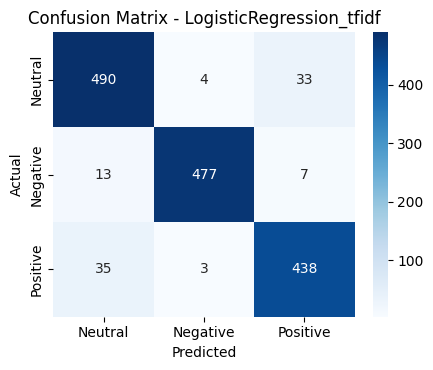


=== LinearSVC_tfidf ===
Accuracy:    0.9353
Precision:   0.9359
Recall:      0.9353
F1-score:    0.9356

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       527
           1       0.98      0.96      0.97       497
           2       0.91      0.92      0.92       476

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



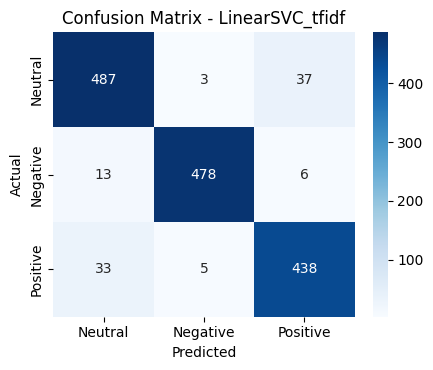


=== MultinomialNB_tfidf ===
Accuracy:    0.9160
Precision:   0.9164
Recall:      0.9174
F1-score:    0.9161

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       527
           1       0.95      0.96      0.96       497
           2       0.87      0.93      0.90       476

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



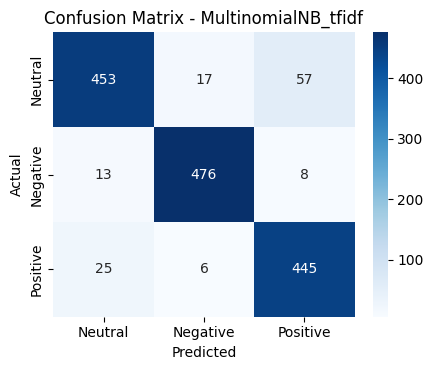


=== RidgeClassifier_tfidf ===
Accuracy:    0.9300
Precision:   0.9307
Recall:      0.9300
F1-score:    0.9302

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       527
           1       0.98      0.96      0.97       497
           2       0.90      0.91      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



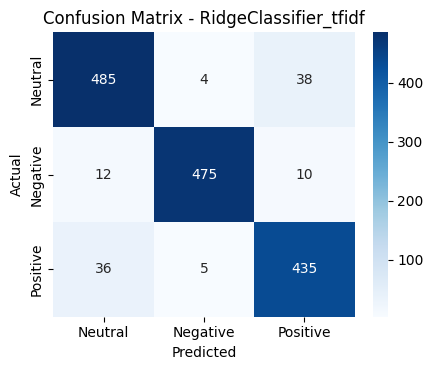


=== PassiveAggressive_tfidf ===
Accuracy:    0.9260
Precision:   0.9261
Recall:      0.9263
F1-score:    0.9262

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       527
           1       0.97      0.96      0.97       497
           2       0.90      0.91      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



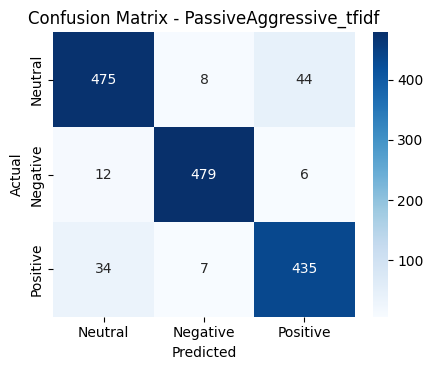


=== LogisticRegression_bow ===
Accuracy:    0.9307
Precision:   0.9316
Recall:      0.9307
F1-score:    0.9310

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91       527
           1       0.99      0.96      0.97       497
           2       0.90      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



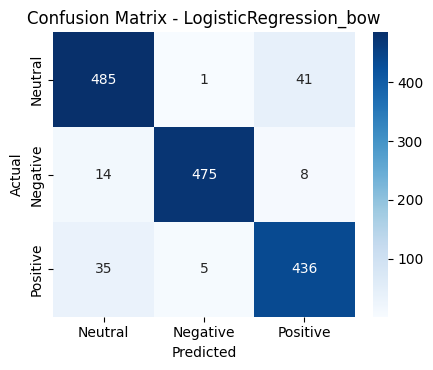


=== LinearSVC_bow ===
Accuracy:    0.9267
Precision:   0.9269
Recall:      0.9270
F1-score:    0.9269

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       527
           1       0.97      0.96      0.96       497
           2       0.89      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



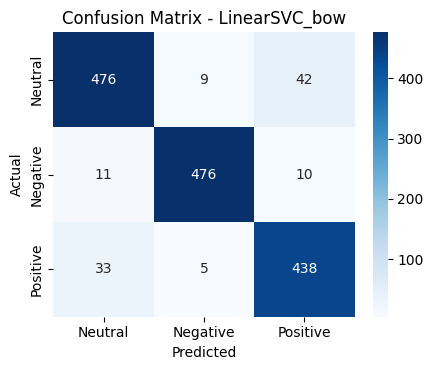


=== MultinomialNB_bow ===
Accuracy:    0.9013
Precision:   0.9024
Recall:      0.9035
F1-score:    0.9012

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.82      0.87       527
           1       0.94      0.96      0.95       497
           2       0.85      0.93      0.89       476

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



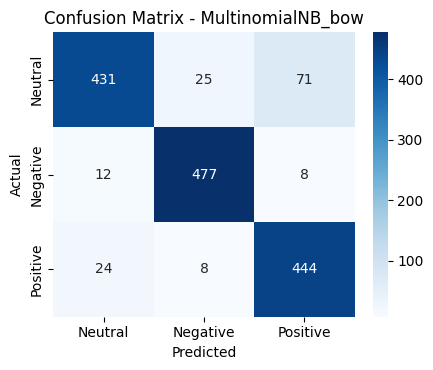


=== RidgeClassifier_bow ===
Accuracy:    0.9253
Precision:   0.9262
Recall:      0.9257
F1-score:    0.9257

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       527
           1       0.99      0.95      0.97       497
           2       0.88      0.92      0.90       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



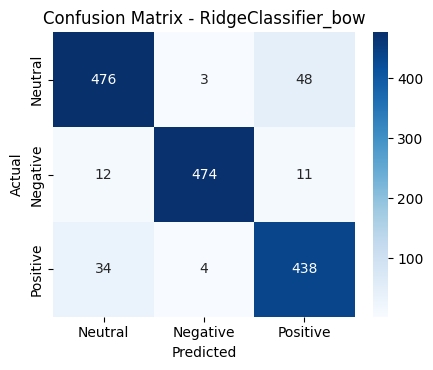


=== PassiveAggressive_bow ===
Accuracy:    0.9233
Precision:   0.9235
Recall:      0.9243
F1-score:    0.9234

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90       527
           1       0.96      0.96      0.96       497
           2       0.88      0.93      0.90       476

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



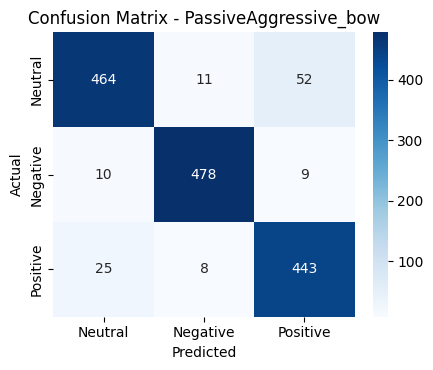

In [21]:
# === EVALUATION OF ALL MODELS (with Confusion Matrix Plot) ===
eval_results = []

for name, preds in val_predictions.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, average='macro', zero_division=0)
    rec = recall_score(y_val, preds, average='macro', zero_division=0)
    f1 = f1_score(y_val, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_val, preds)

    print(f"\n=== {name} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1-score:    {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, preds, zero_division=0))

    # ---- Improved Confusion Matrix ----
    # Tick labels (0 = Neutral, 1 = Negative, 2 = Positive)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=['Neutral', 'Negative', 'Positive'],
                yticklabels=['Neutral', 'Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    # -----------------------------------

    eval_results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
    })


# **10. Picking the best Model**

Best TF-IDF model on validation: LogisticRegression_tfidf
Selected final model for testing: LogisticRegression_tfidf

Final Test Metrics:
Accuracy : 0.9353
Precision: 0.9354
Recall   : 0.9357
F1 Score : 0.9355


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


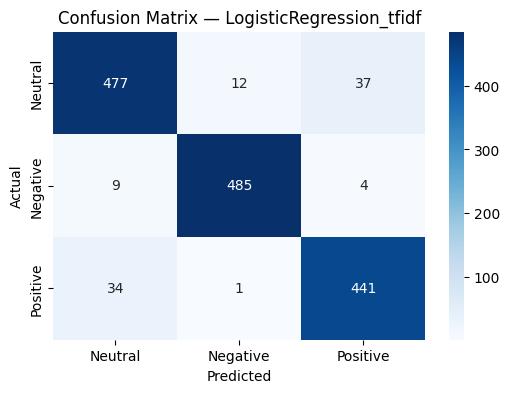

In [22]:
# ==========================================
# PICK BEST TF-IDF MODEL & EVALUATE ON TEST
# ==========================================

# Filter TF-IDF models and pick best by F1 (using f1_score for multiclass)
best = max(
    (r for r in eval_results if "_tfidf" in r["model"]),
    key=lambda x: x["f1_score"]
)
print("Best TF-IDF model on validation:", best["model"])

# Retrieve the trained model directly from the dictionary
final_model = trained_models[best["model"]]
print(f"Selected final model for testing: {best['model']}")

# Merge train + validation data
from scipy.sparse import vstack
X_train_val_tfidf = vstack([X_train_tfidf, X_val_tfidf])
y_train_val = np.concatenate([y_train, y_val])

# Train final model on combined data (re-train for final evaluation on test set)
final_model.fit(X_train_val_tfidf, y_train_val)

# Predict on test
test_preds = final_model.predict(X_test_tfidf)

# ===================
# METRICS
# ===================
print("\nFinal Test Metrics:")
print(f"Accuracy : {accuracy_score(y_test, test_preds):.4f}")
# Ensure average is 'macro' for multiclass metrics
print(f"Precision: {precision_score(y_test, test_preds, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, test_preds, average='macro', zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, test_preds, average='macro', zero_division=0):.4f}")

# ===================
# CONFUSION MATRIX HEATMAP
# ===================
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Neutral', 'Negative', 'Positive'], # Corrected for 3 classes
            yticklabels=['Neutral', 'Negative', 'Positive']) # Corrected for 3 classes
plt.title(f"Confusion Matrix — {best['model']}") # Use best['model'] for title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **11. XAI SHAP on Best Classical Model**

Initializing SHAP explainer...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


SHAP values computed.


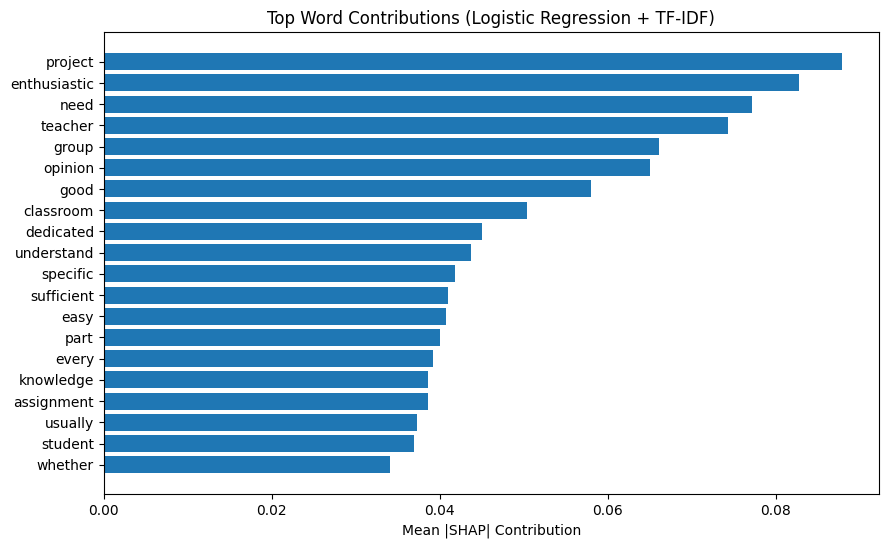

In [23]:
# === SHAP for Logistic Regression + TF-IDF ===
print("Initializing SHAP explainer...")

# pick your desired TF-IDF model
final_model = trained_models["LogisticRegression_tfidf"]

# SHAP can use sparse matrices directly (safer)
X_train_sample = X_train_tfidf[:500]  # keep sparse
X_test_sample = X_test_tfidf          # keep sparse

# create multiclass-compatible explainer
explainer = shap.LinearExplainer(
    final_model,
    X_train_sample,
    feature_perturbation="interventional",
    model_output="raw"   # important for multiclass
)

# compute SHAP values for test set
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed.")

# === GLOBAL FEATURE IMPORTANCE ===

feature_names = tfidf.get_feature_names_out()

if isinstance(shap_values, list):
    # SHAP gives a list of = num_classes arrays
    abs_vals = [np.abs(v) for v in shap_values]
    stacked = np.stack(abs_vals)            # (C, N, F)
    global_shap_values = stacked.mean(axis=(0, 1))
else:
    # SHAP gives a single tensor (N, F, C)
    global_shap_values = np.abs(shap_values).mean(axis=(0, 2))

# Top tokens
N = 20
sorted_idx = np.argsort(global_shap_values)[::-1][:N]
top_tokens = feature_names[sorted_idx]
top_scores = global_shap_values[sorted_idx]

plt.figure(figsize=(10,6))
plt.barh(range(N), top_scores)
plt.yticks(range(N), top_tokens)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP| Contribution")
plt.title("Top Word Contributions (Logistic Regression + TF-IDF)")
plt.show()

# **12. Deep Learning**

In [24]:
# PREP TEXT FOR DEEP LEARNING

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')

# **13. CNN Model**

In [26]:
# TRAINING CNN MODEL (3-class)

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")  # <-- 3 classes
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # <-- for integer labels (0,1,2)
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7252 - loss: 0.7423 - val_accuracy: 0.9273 - val_loss: 0.1895
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9459 - loss: 0.1603 - val_accuracy: 0.9300 - val_loss: 0.1865
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9720 - loss: 0.0900 - val_accuracy: 0.9300 - val_loss: 0.1902
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9828 - loss: 0.0564 - val_accuracy: 0.9293 - val_loss: 0.2055
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9313 - val_loss: 0.2200
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9913 - loss: 0.0259 - val_accuracy: 0.9300 - val_loss: 0.2579
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9949 - loss: 0.0194 - val_accuracy: 0.9280 - val_loss: 0.2834
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9963 - loss: 0.0148 - val_accuracy: 

# **14. Evaluate CNN Model**

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

📌 CNN Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90       526
    Positive       0.97      0.97      0.97       498
     Neutral       0.90      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



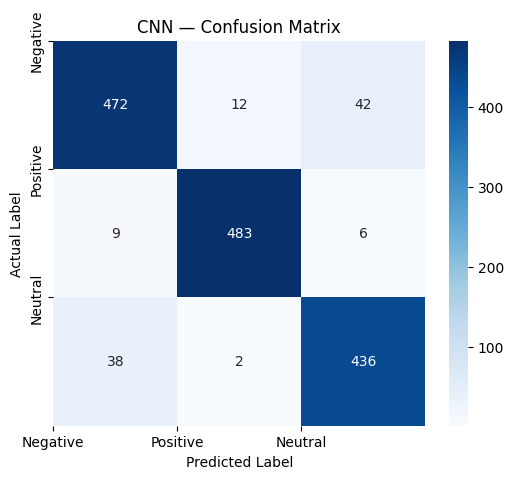

In [27]:
# Prepare test set for CNN
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post'
)

# Predict probabilities (shape: [n_samples, 3])
y_pred_probs = cnn_model.predict(X_test_pad)

# Get class with highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# CNN Classification Report
print("\n📌 CNN Classification Report:")
target_names = ['Negative', 'Positive', 'Neutral']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("CNN — Confusion Matrix")
plt.xticks(np.arange(3), target_names)
plt.yticks(np.arange(3), target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# **15. LSTM Model**

In [28]:
# ==========================
# CLASS WEIGHTS (HANDLE IMBALANCE)
# ==========================
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.949667616334283), np.int64(1): np.float64(1.0048808498420903), np.int64(2): np.float64(1.05057781779979)}


In [29]:
# Training LSTM
lstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer=Adam(1e-4),  # Smaller LR prevents collapse
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4240 - loss: 1.0864 - val_accuracy: 0.8307 - val_loss: 1.0147
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7735 - loss: 0.9087 - val_accuracy: 0.8060 - val_loss: 0.4856
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7916 - loss: 0.5406 - val_accuracy: 0.8887 - val_loss: 0.3371
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8859 - loss: 0.3238 - val_accuracy: 0.9100 - val_loss: 0.2509
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9077 - loss: 0.2619 - val_accuracy: 0.9180 - val_loss: 0.2403
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9184 - loss: 0.2451 - val_accuracy: 0.9240 - val_loss: 0.2308
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9316 - loss: 0.2162 - val_accuracy: 0.9213 - val_loss: 0.2276
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9350 - loss: 0.2099 - val_accuracy: 0.924

# **16. Evaluating LSTM**

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

📌 LSTM Classification Report:
              precision    recall  f1-score   support

     Neutral       0.91      0.89      0.90       526
    Negative       0.98      0.96      0.97       498
    Positive       0.89      0.93      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



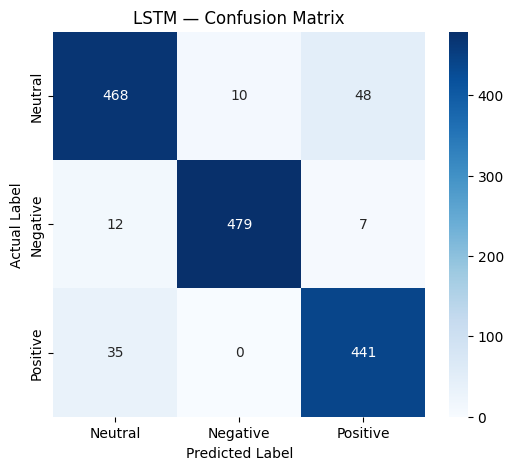

In [30]:
# Prepare test set
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post'
)

# Predict softmax distributions
y_pred_probs = lstm_model.predict(X_test_pad)

# Convert to label IDs
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\n📌 LSTM Classification Report:")
target_names = ['Neutral', 'Negative', 'Positive']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM — Confusion Matrix")
plt.xticks(np.arange(3) + 0.5, target_names)
plt.yticks(np.arange(3) + 0.5, target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


# **17. DistilBERT Model**

In [31]:
# ---------- Settings ----------
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 3
MAX_LEN = 128
BATCH_SIZE = 16          # reduce to 8 if OOM
EPOCHS = 3
LR = 3e-5
SAVE_DIR = "/content/distilbert_finetuned"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- Expect variables already in notebook ----------
# X_train, X_val, X_test  -> arrays/lists of cleaned text
# y_train, y_val, y_test  -> numpy arrays or lists of integer labels {0,1,2}
# If they are not defined, make sure to create them earlier (from your split).
assert 'X_train' in globals() and 'y_train' in globals(), "Make sure X_train and y_train exist."

Device: cuda


In [32]:
# ---------- Tokenizer ----------
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_texts(texts, max_length=MAX_LEN):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

# ---------- Create PyTorch Dataset ----------
class SimpleTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Tokenize datasets
train_enc = tokenize_texts(X_train)
val_enc   = tokenize_texts(X_val)
test_enc  = tokenize_texts(X_test)

train_dataset = SimpleTextDataset(train_enc, y_train)
val_dataset   = SimpleTextDataset(val_enc, y_val)
test_dataset  = SimpleTextDataset(test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [33]:
# ---------- Model ----------
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
model.to(device)

# ---------- Class weights (for CrossEntropy) ----------
counts = Counter(y_train)
# create weight per label: inverse frequency
label_freqs = np.array([counts.get(i, 0) for i in range(NUM_LABELS)], dtype=np.float32)
print("Label counts (train):", dict(counts))
# avoid division by zero
label_freqs = np.where(label_freqs == 0, 1.0, label_freqs)
weights = 1.0 / label_freqs
# normalize
weights = weights / weights.sum() * NUM_LABELS
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights.cpu().numpy())

criterion = CrossEntropyLoss(weight=class_weights)

# ---------- Optimizer & scheduler ----------
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.06 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# ---------- Training loop ----------
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    losses = []
    for batch in tqdm(loader, desc="train", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        logits = outputs.logits
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())
    return np.mean(losses)

def eval_model(model, loader):
    model.eval()
    preds = []
    trues = []
    losses = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="eval", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = outputs.logits
            loss = criterion(logits, labels)
            losses.append(loss.item())

            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            preds.extend(batch_preds.tolist())
            trues.extend(labels.cpu().numpy().tolist())
    return {
        "loss": np.mean(losses),
        "preds": np.array(preds),
        "trues": np.array(trues)
    }

best_val_f1 = -1.0
history = {"train_loss": [], "val_loss": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{EPOCHS} ===")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    val_res = eval_model(model, val_loader)

    val_preds = val_res["preds"]
    val_trues = val_res["trues"]
    val_loss = val_res["loss"]

    val_acc = accuracy_score(val_trues, val_preds)
    val_prec = precision_score(val_trues, val_preds, average='macro', zero_division=0)
    val_rec = recall_score(val_trues, val_preds, average='macro', zero_division=0)
    val_f1 = f1_score(val_trues, val_preds, average='macro', zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}  |  Val F1 (macro): {val_f1:.4f}")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        os.makedirs(SAVE_DIR, exist_ok=True)
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print("Saved best model to", SAVE_DIR)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Label counts (train): {np.int64(0): 2457, np.int64(2): 2221, np.int64(1): 2322}
Class weights: [0.94804764 1.0031667  1.0487857 ]

=== Epoch 1/3 ===


train:   0%|          | 0/438 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Train loss: 0.1058  |  Val loss: 0.1519
Val Acc: 0.9460  |  Val F1 (macro): 0.9464
Saved best model to /content/distilbert_finetuned

=== Epoch 3/3 ===


train:   0%|          | 0/438 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Train loss: 0.0604  |  Val loss: 0.1806
Val Acc: 0.9447  |  Val F1 (macro): 0.9450


# **18. Evaluating DistilBERT Model**


=== Final Evaluation on TEST SET ===


eval:   0%|          | 0/94 [00:00<?, ?it/s]

Test Acc: 0.9467  |  Test F1 (macro): 0.9468

Classification Report:

              precision    recall  f1-score   support

     Neutral       0.93      0.92      0.93       526
    Negative       0.98      0.98      0.98       498
    Positive       0.93      0.94      0.93       476

    accuracy                           0.95      1500
   macro avg       0.95      0.95      0.95      1500
weighted avg       0.95      0.95      0.95      1500



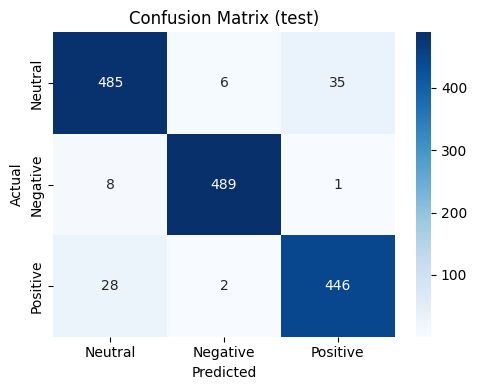

Model and tokenizer saved to: /content/distilbert_finetuned


In [38]:
# ---------- Final evaluation on TEST ----------
print("\n=== Final Evaluation on TEST SET ===")
test_res = eval_model(model, test_loader)
test_preds = test_res["preds"]
test_trues = test_res["trues"]

test_acc = accuracy_score(test_trues, test_preds)
test_prec = precision_score(test_trues, test_preds, average='macro', zero_division=0)
test_rec = recall_score(test_trues, test_preds, average='macro', zero_division=0)
test_f1 = f1_score(test_trues, test_preds, average='macro', zero_division=0)

print(f"Test Acc: {test_acc:.4f}  |  Test F1 (macro): {test_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(test_trues, test_preds, target_names=['Neutral','Negative','Positive'], zero_division=0))


# Plot confusion matrix (clean version)
cm = confusion_matrix(test_trues, test_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral','Negative','Positive'],
            yticklabels=['Neutral','Negative','Positive'])
plt.title("Confusion Matrix (test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Model and tokenizer saved to:", SAVE_DIR)